### Подключение модулей

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import tensorflow as tf
from tensorflow import keras

Целью этого проекта является прогнозирование и анализ цен продажи жилья в США. Требуется построить регрессионную модель для прогнозирования цен на жилье в США на основе различных факторов.


### Загрузка данных

In [8]:
df = pd.read_csv('USA_Housing.csv')

In [9]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


Данные содержат следующие столбцы:
- __Avg. Area Income__ (Сред. Доход от района): Средний доход жителей города по региону.
- __Avg. Area House Age__ (Сред. Площадь дома): Средний возраст домов в районе.
- __Avg. Area Number of Rooms__ (Сред. Площадь Количество комнат): Среднее количество комнат в домах в том же городе.
- __Avg. Area Number of Bedrooms__ (Сред. Площадь Количество спален): Среднее количество спален в домах в том же городе.
- __Area Population__ (Население региона): Население городского дома, в котором находится.
- __Price__ (Цена): Цена, по которой был продан дом.
- __Address__ (Адрес): Адрес дома.
    

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [11]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [12]:
pd.set_option('display.float_format', lambda x: '%0.4f' % x)

In [13]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,68583.1090,5.9772,6.9878,3.9813,36163.5160,1232072.6541
std,10657.9912,0.9915,1.0058,1.2341,9925.6501,353117.6266
min,17796.6312,2.6443,3.2362,2.0000,172.6107,15938.6579
25%,61480.5624,5.3223,6.2993,3.1400,29403.9287,997577.1350
50%,68804.2864,5.9704,7.0029,4.0500,36199.4067,1232669.3780
75%,75783.3387,6.6508,7.6659,4.4900,42861.2908,1471210.2042
max,107701.7484,9.5191,10.7596,6.5000,69621.7134,2469065.5942


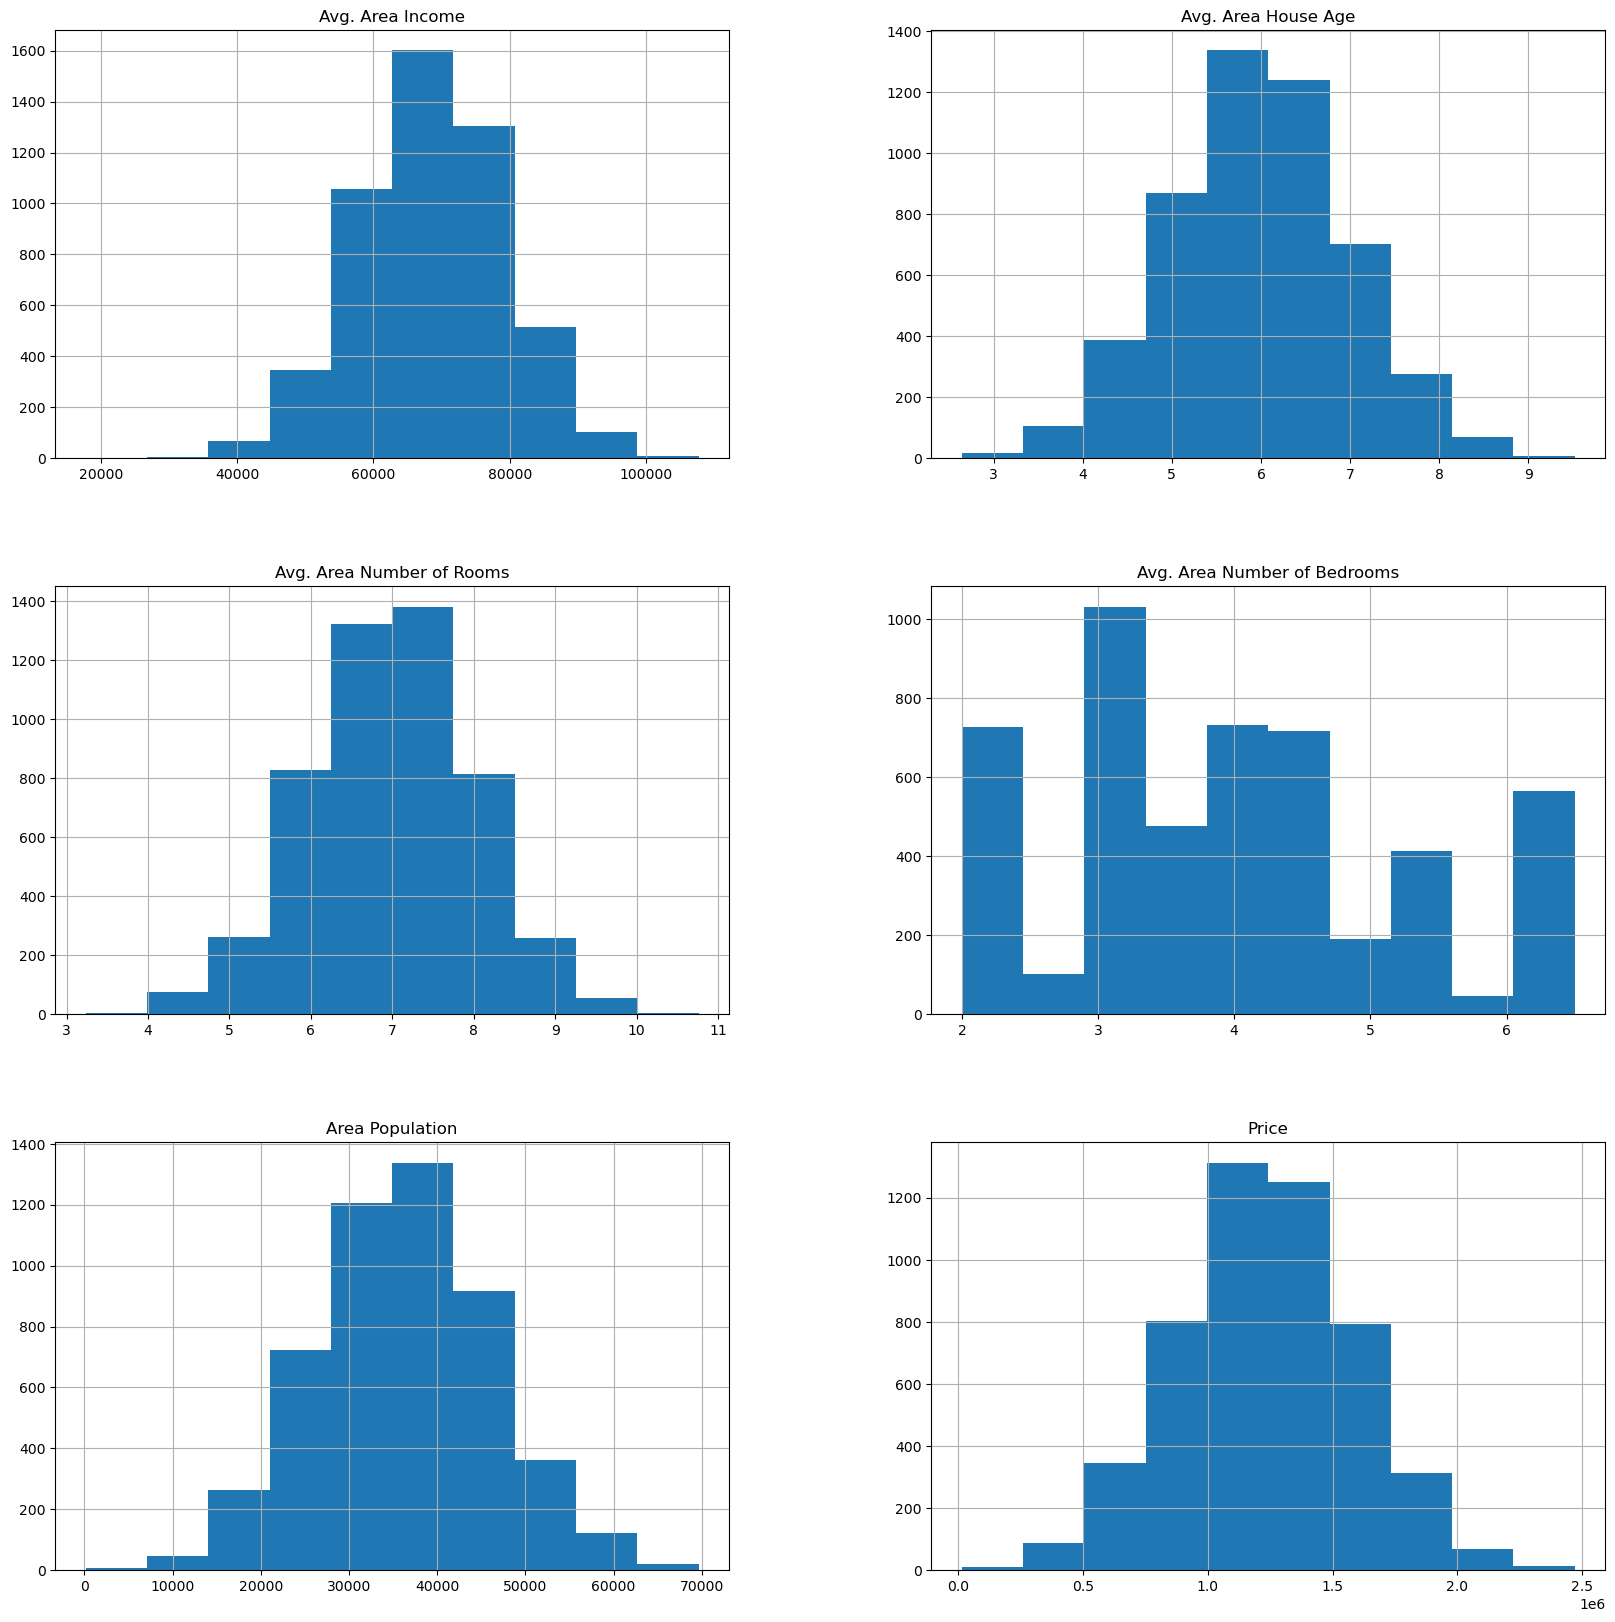

In [21]:
df.hist(figsize=(20,20));

<Figure size 800x600 with 0 Axes>

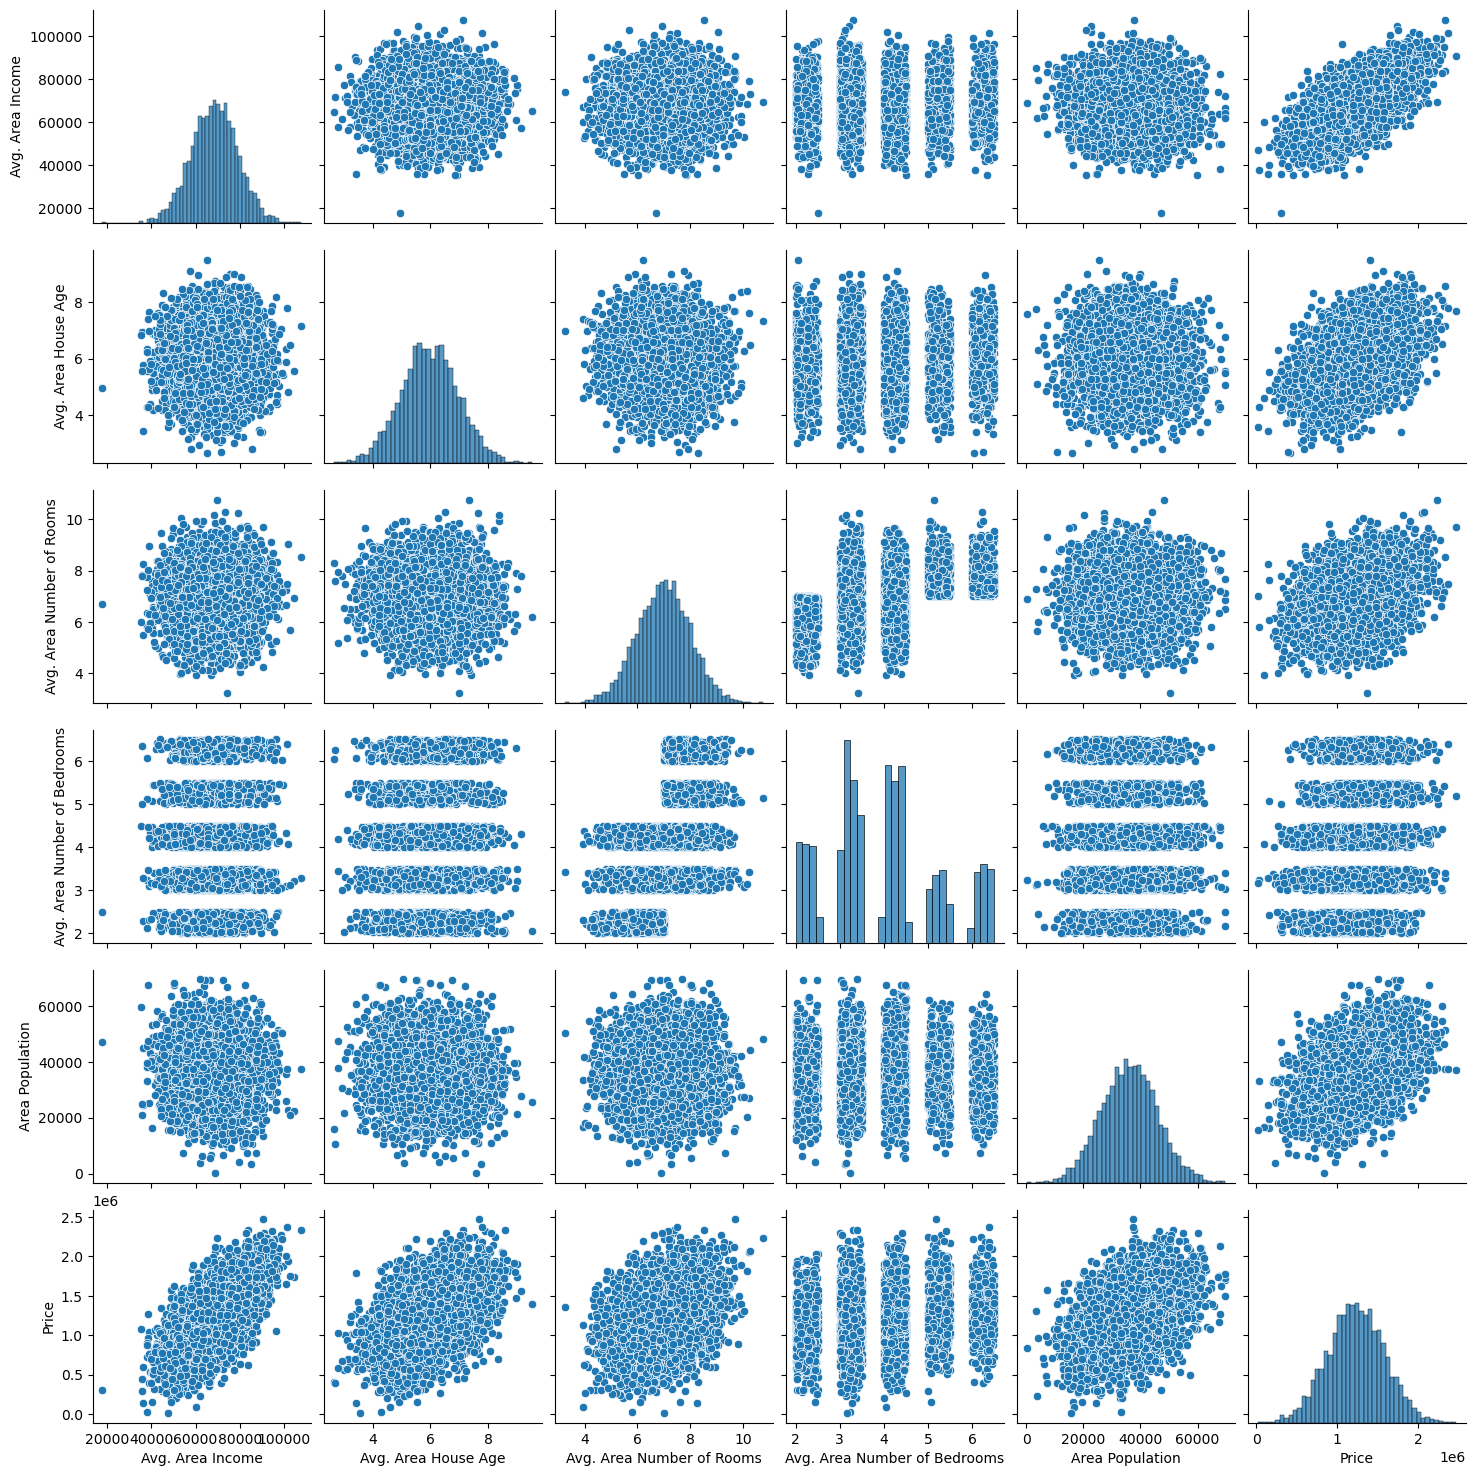

In [23]:
plt.figure(figsize=(8,6))
sns.pairplot(df)

<Axes: xlabel='Price', ylabel='Density'>

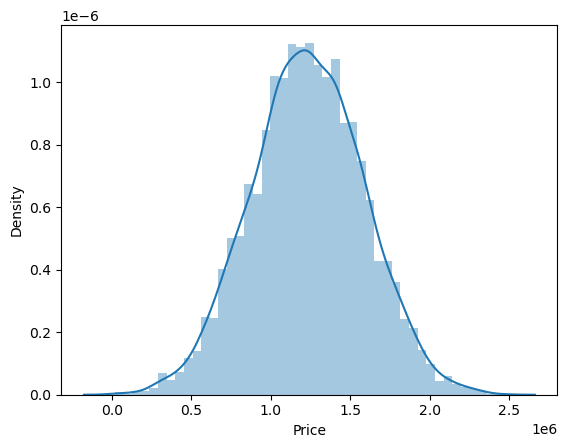

In [23]:
sns.distplot(df['Price'])

<Axes: xlabel='Avg. Area Income', ylabel='Price'>

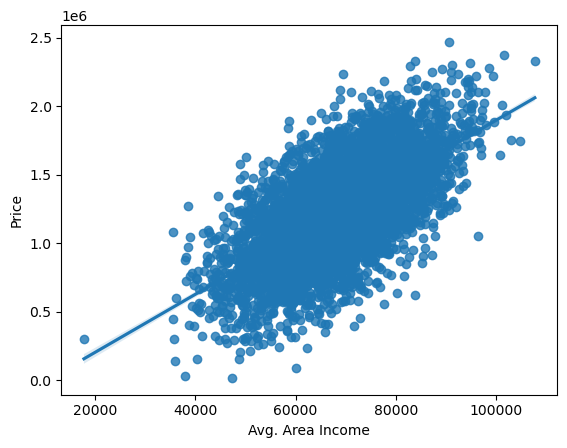

In [25]:
sns.regplot(y='Price', x='Avg. Area Income', data=df)

In [27]:
df[['Avg. Area Income', 'Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population', 'Price']].corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.0000,-0.0020,-0.0110,0.0198,-0.0162,0.6397
Avg. Area House Age,-0.0020,1.0000,-0.0094,0.0061,-0.0187,0.4525
Avg. Area Number of Rooms,-0.0110,-0.0094,1.0000,0.4627,0.0020,0.3357
Avg. Area Number of Bedrooms,0.0198,0.0061,0.4627,1.0000,-0.0222,0.1711
Area Population,-0.0162,-0.0187,0.0020,-0.0222,1.0000,0.4086
Price,0.6397,0.4525,0.3357,0.1711,0.4086,1.0000


<Axes: >

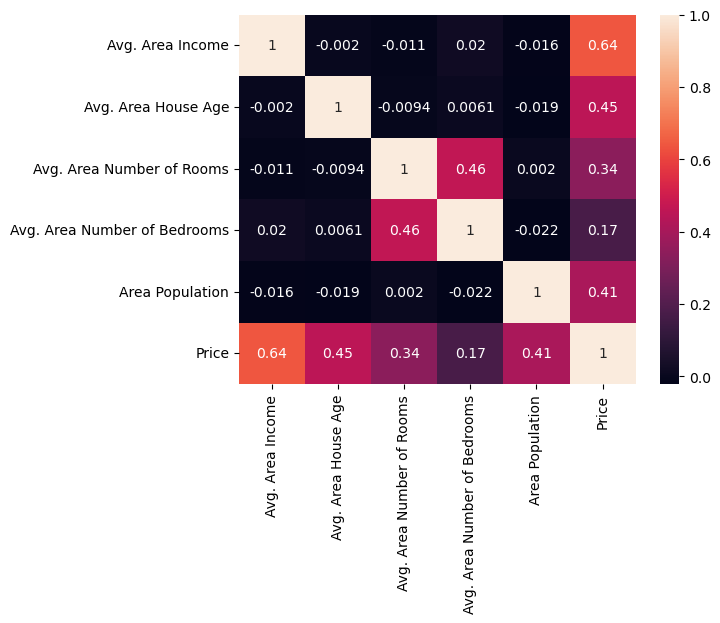

In [29]:
sns.heatmap(df[['Avg. Area Income', 'Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population', 'Price']].corr(), annot=True)

In [31]:
df['House Age'] = df['Avg. Area House Age'].apply(int)

<Axes: xlabel='House Age', ylabel='Price'>

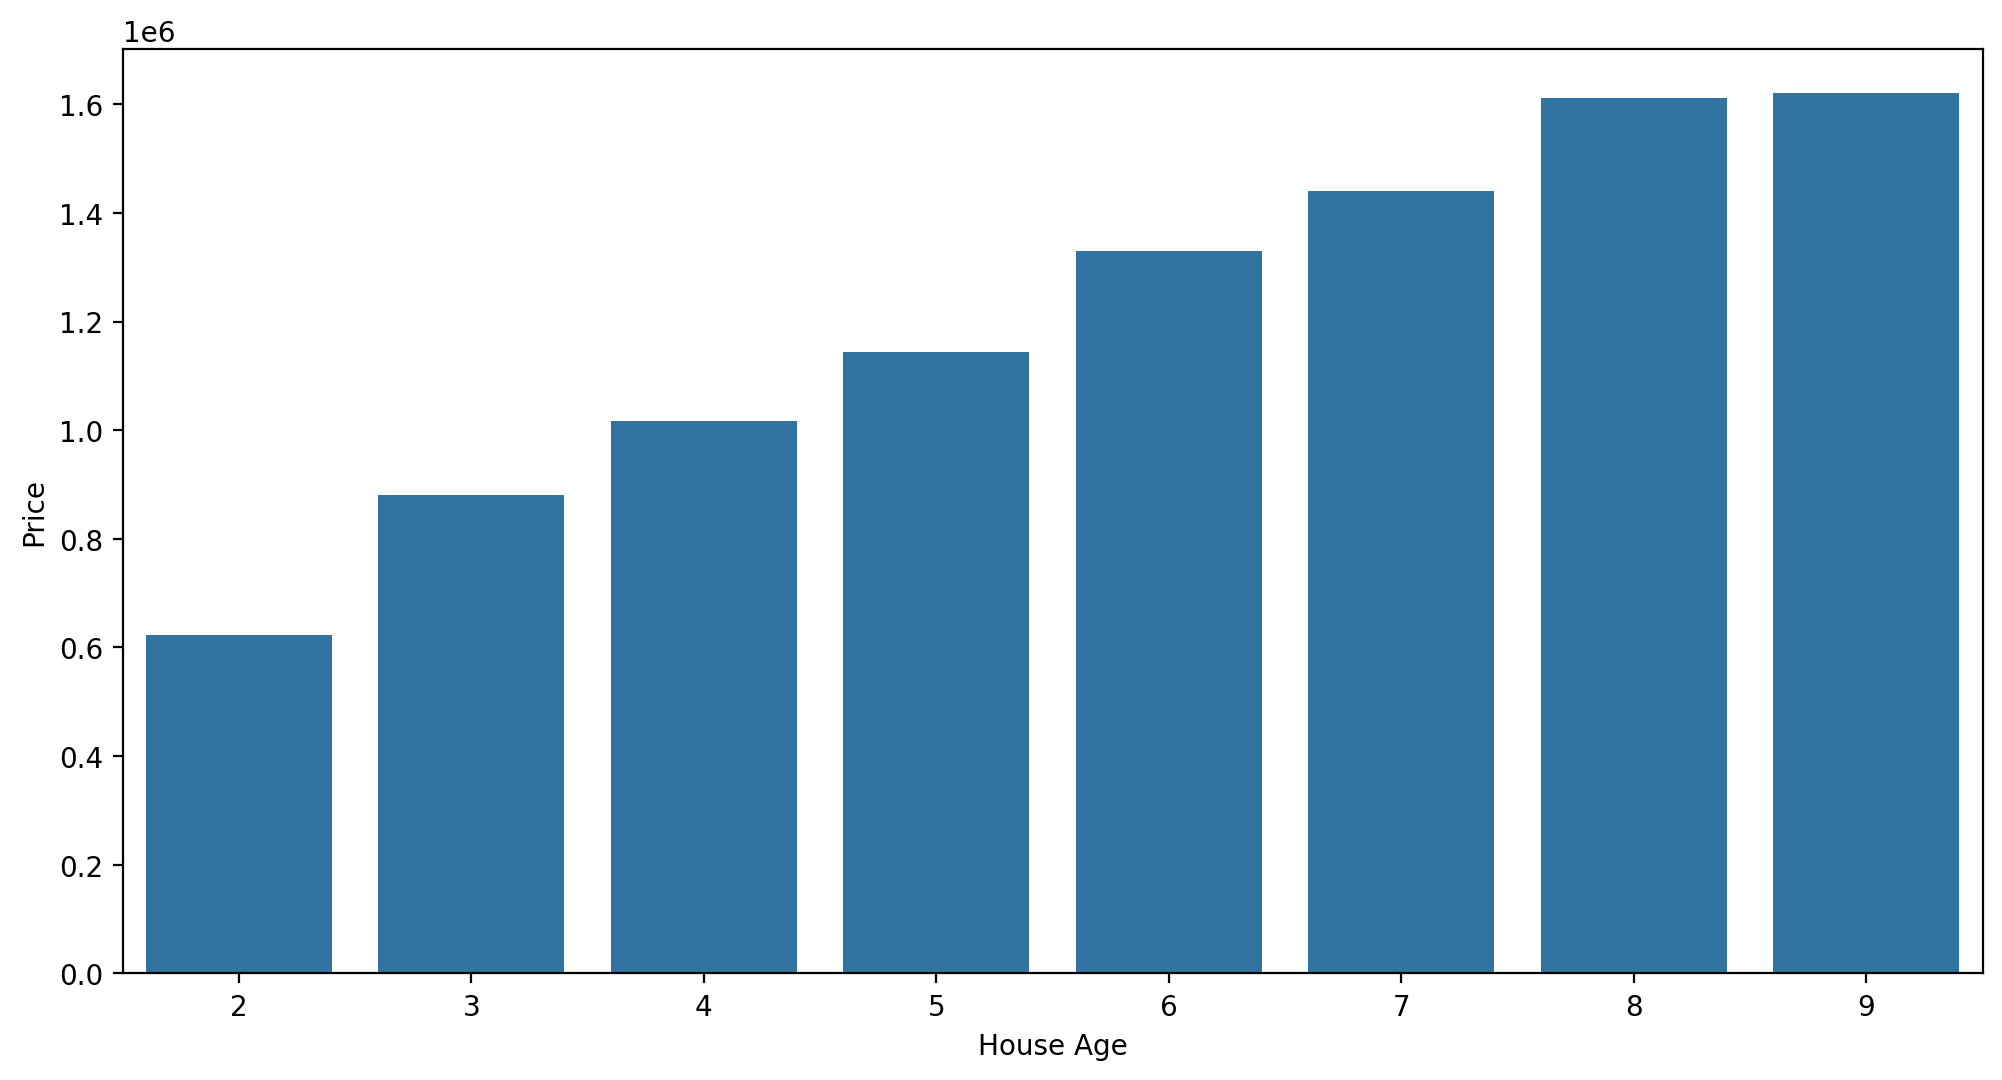

In [33]:
plt.figure(figsize = (12, 6), dpi = 200)
sns.barplot(x = 'House Age', y = 'Price', data = df, ci = None)

In [35]:
df['Number of Rooms'] = df['Avg. Area Number of Rooms'].apply(int)

<Axes: xlabel='Number of Rooms', ylabel='Price'>

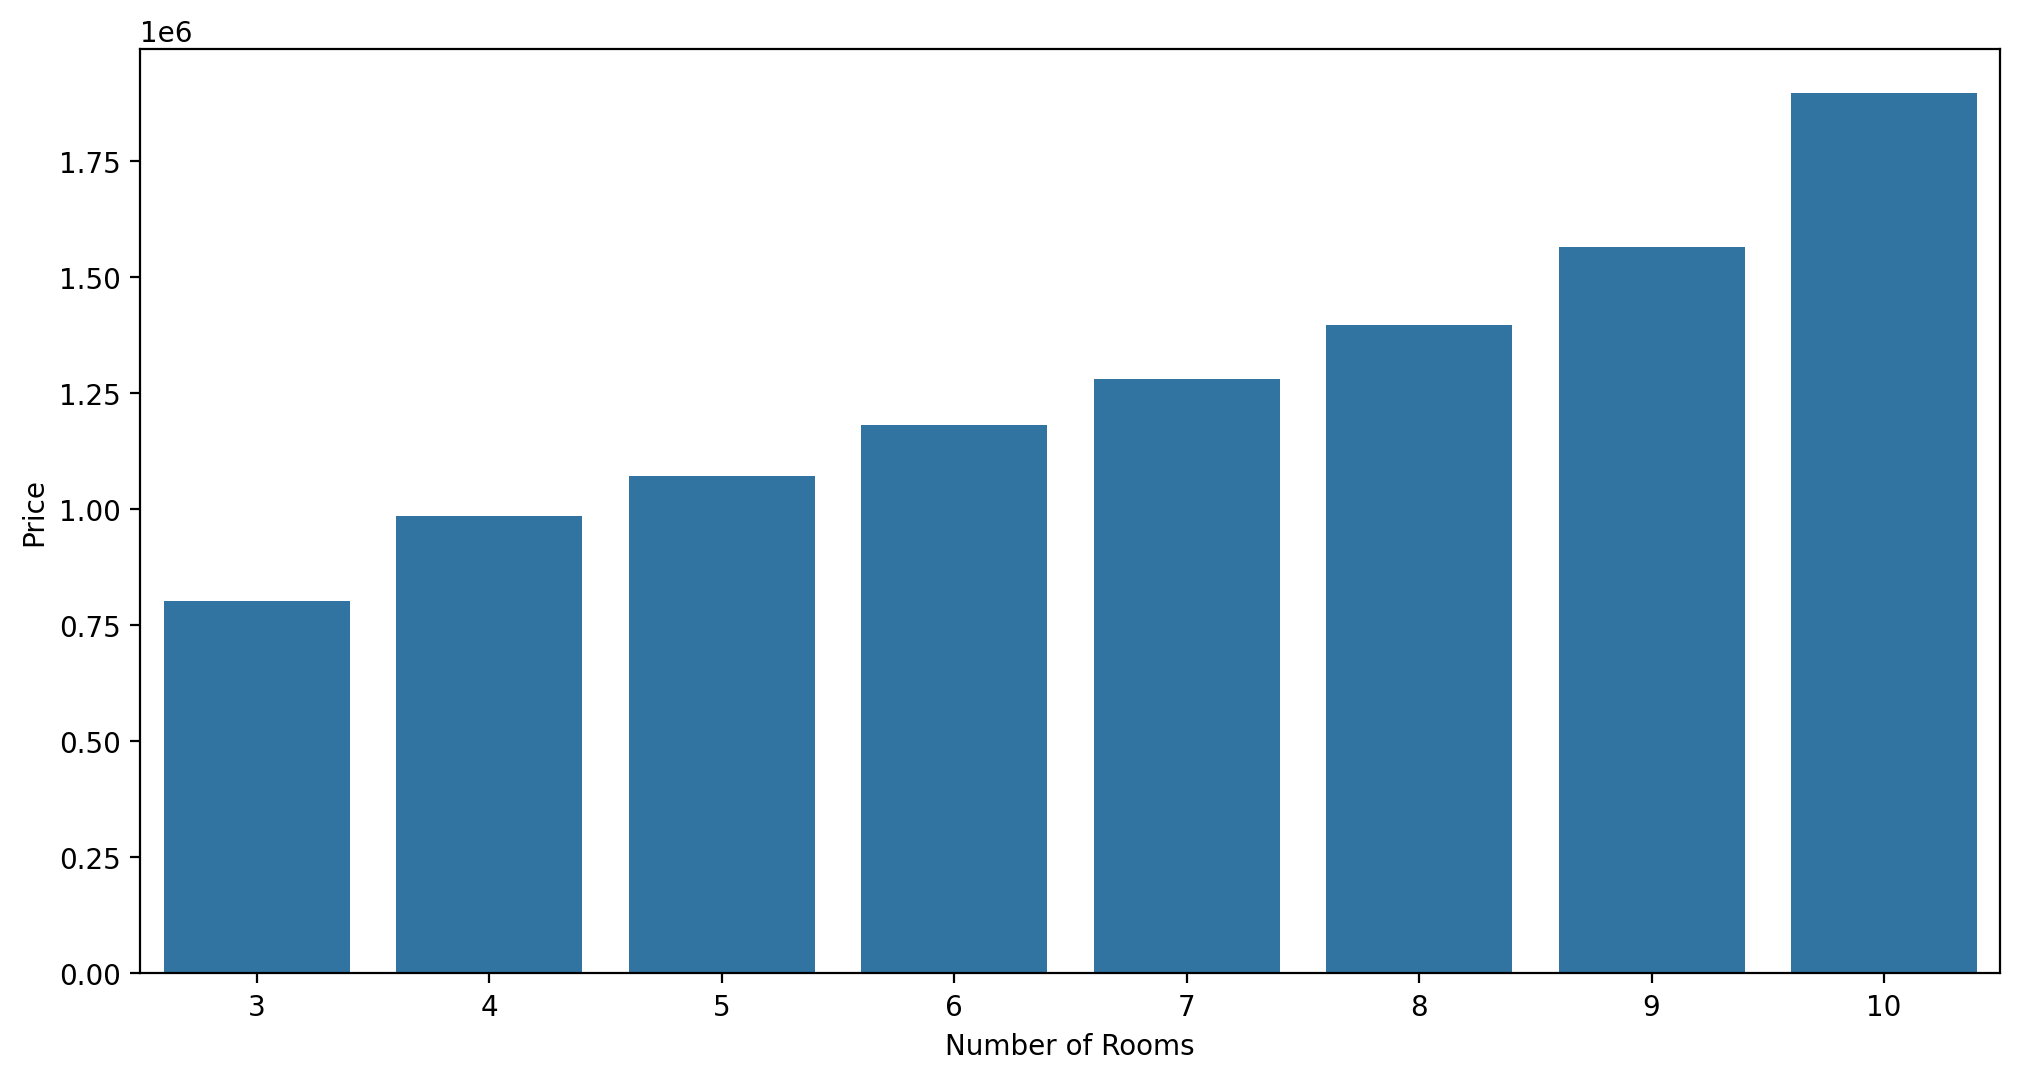

In [37]:
plt.figure(figsize = (12, 6), dpi = 200)
sns.barplot(x = 'Number of Rooms', y = 'Price', data = df, ci = None)

In [38]:
df['Number of Bedrooms'] = df['Avg. Area Number of Bedrooms'].apply(int)

<Axes: xlabel='Number of Bedrooms', ylabel='Price'>

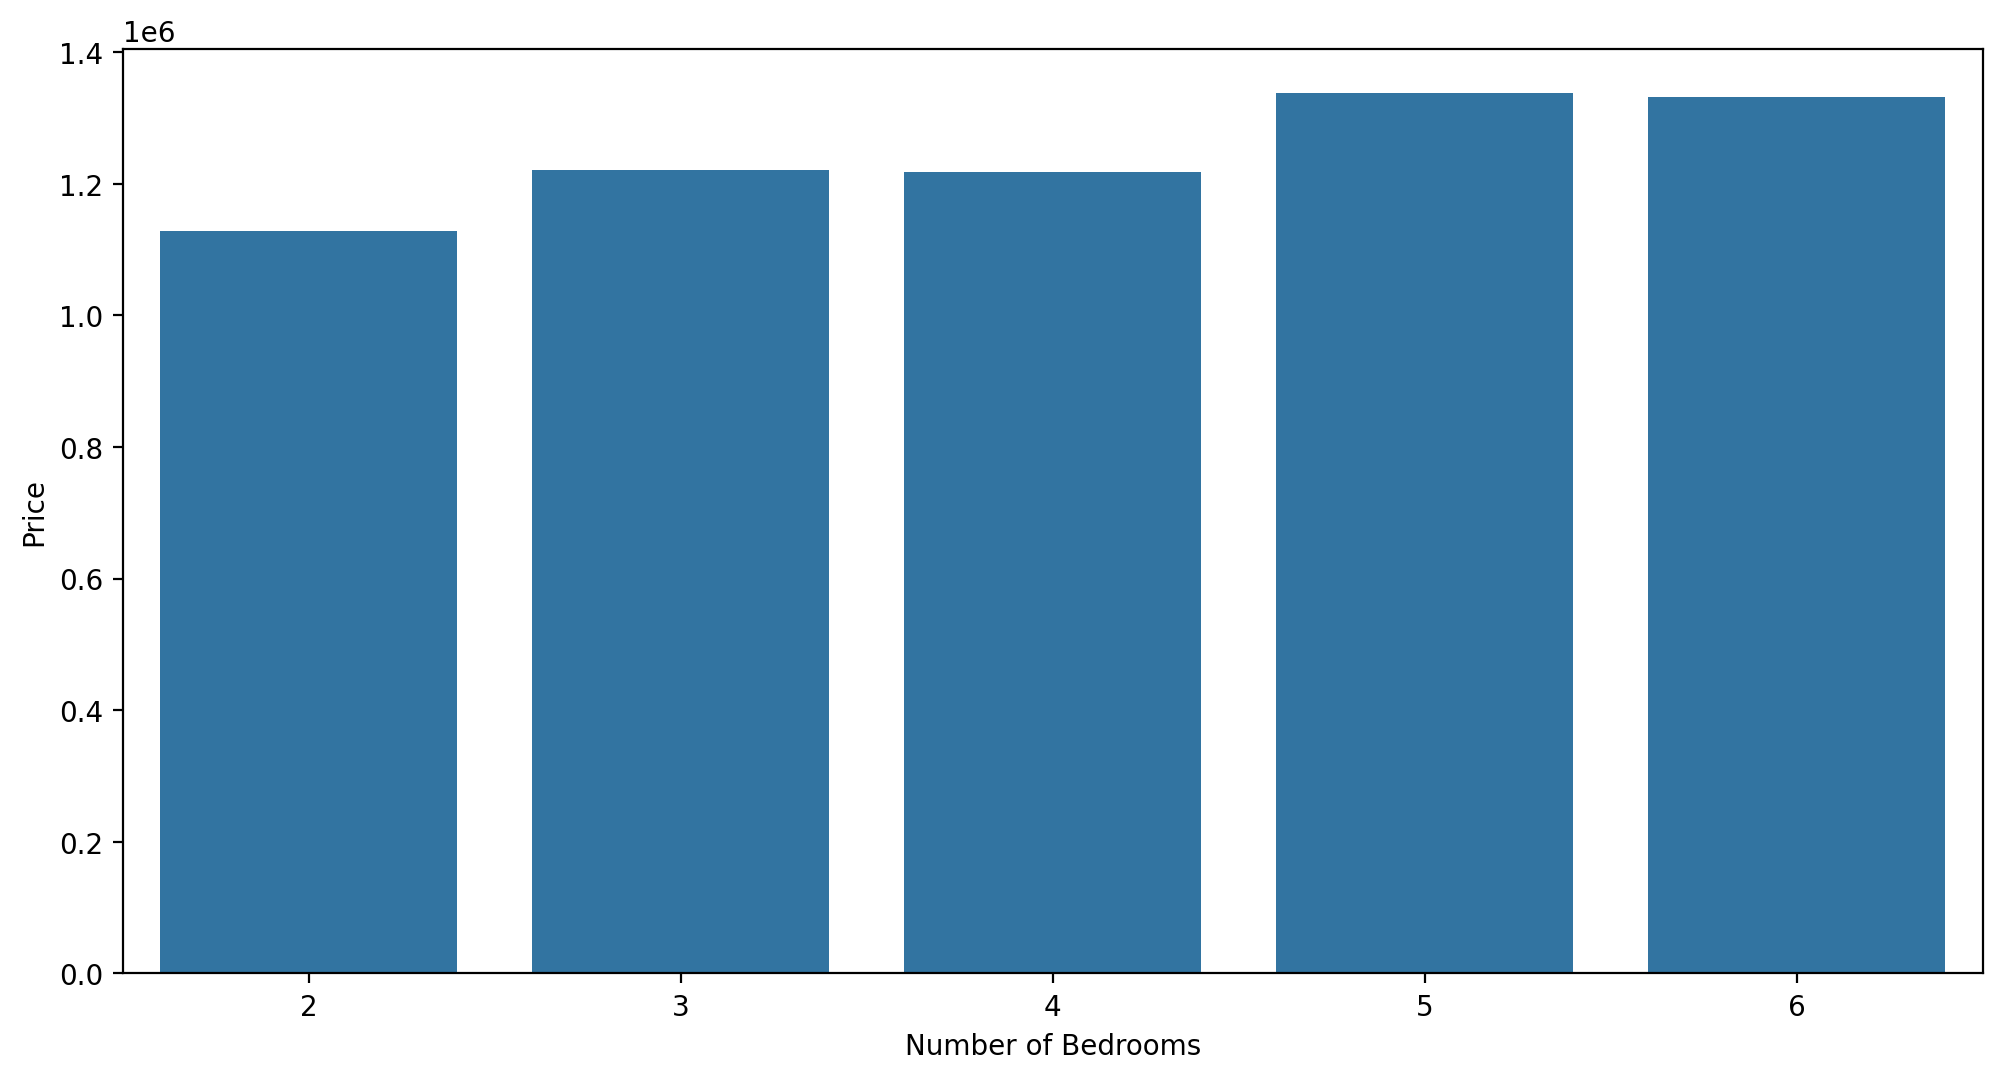

In [39]:
plt.figure(figsize = (12, 6), dpi = 200)
sns.barplot(x = 'Number of Bedrooms', y = 'Price', data = df, ci = None)

### Обучение модели линейной регрессии

In [44]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address',
       'House Age', 'Number of Rooms', 'Number of Bedrooms'],
      dtype='object')

In [46]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]

In [48]:
y = df['Price']

In [50]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Линейная регрессия

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
lrm = LinearRegression()
lrm.fit(X_train, y_train)

LinearRegression()

In [59]:
lrm.intercept_

-2638673.426190405

In [61]:
lrm.coef_

array([2.16257989e+01, 1.65590393e+05, 1.19827783e+05, 2.36109526e+03,
       1.52165814e+01])

In [63]:
predictions = lrm.predict(X_test)

In [65]:
predictions

array([1308536.13592598, 1237122.72746455, 1243835.62817085, ...,
       1457119.79297219, 1483428.9530929 , 1047510.5973721 ])

In [67]:
y_test.round(3)

1501   1339096.0770
2586   1251794.1790
2653   1340094.9660
1055   1431507.6230
705    1042373.5240
           ...     
3563   1348221.7650
1538   1309937.3990
1837   1472887.2470
2380   1409762.1190
1912   1009606.2840
Name: Price, Length: 1500, dtype: float64

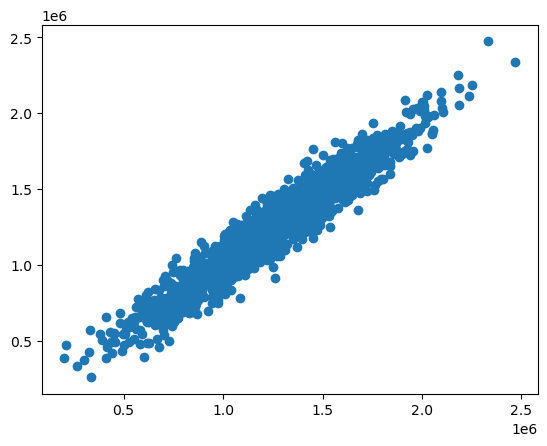

In [69]:
plt.scatter(y_test, predictions)

<Axes: xlabel='Price'>

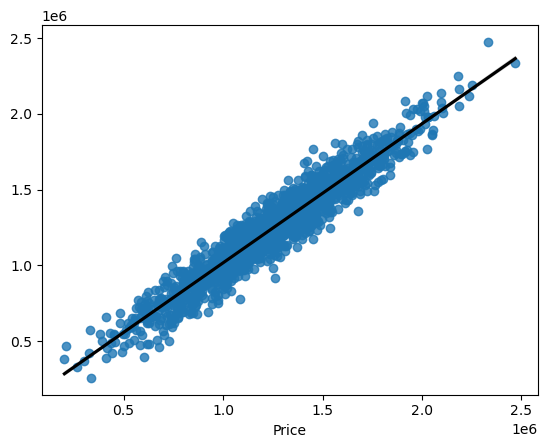

In [70]:
sns.regplot(x=y_test,y=predictions,line_kws={"color":"black"})

<Axes: xlabel='Price', ylabel='Density'>

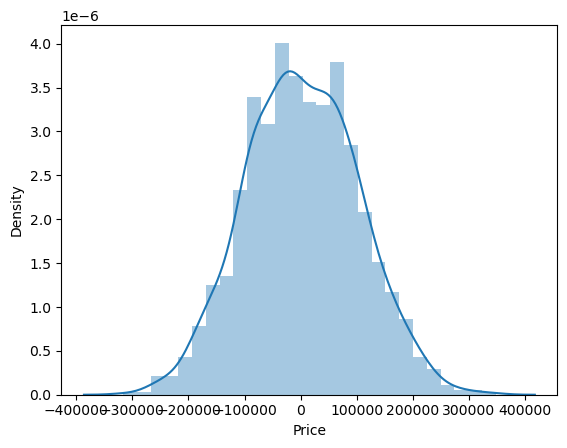

In [72]:
sns.distplot((y_test - predictions))

### Метрики оценки качества регрессии


Общие показатели оценки для задач регрессии:

**Mean Absolute Error** (MAE Средняя абсолютная ошибка) - это среднее значение абсолютного значения ошибок:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE Среднеквадратическая ошибка) - это среднее значение квадратов ошибок:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE Среднеквадратическая ошибка) - это квадратный корень из среднего квадрата ошибок:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

**Коэффициент детерминации** $R^{2}$

$$R^2 = 1 - \frac{\frac{1}{n}\sum^{n}_{i}{(y - y_{pred})^2}}{\frac{1}{n}\sum^{n}_{i}{(y - \bar{y})^2}}$$

In [76]:
from sklearn import metrics

In [78]:
metrics.mean_absolute_error(y_test, predictions)

81135.56609336908

In [80]:
metrics.mean_squared_error(y_test, predictions)

10068422551.400915

In [82]:
np.sqrt(metrics.mean_squared_error(y_test, predictions))

100341.52954485454

In [84]:
metrics.r2_score(y_test, predictions)

0.9146818498754012

Пропущенные значения:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64
=== ОБУЧЕНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ ===
Коэффициенты модели: [2.16257989e+01 1.65590393e+05 1.19827783e+05 2.36109526e+03
 1.52165814e+01]
Свободный член: -2638673.43
MAE: 81,135.57
MSE: 10,068,422,551.40
RMSE: 100,341.53
R²: 0.9147

=== ОБУЧЕНИЕ НЕЙРОННОЙ СЕТИ ===
Архитектура нейронной сети:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2734 - mae: 0.3876 - val_loss: 0.0902 - val_mae: 0.2421
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1275 - mae: 0.2835 - val_loss: 0.0879 - val_mae: 0.2383
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1197 - mae: 0.2755 - val_loss: 0.0918 - val_mae: 0.2415
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1105 - mae: 0.2644 - val_loss: 0.0869 - val_mae: 0.2373
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1069 - mae: 0.2609 - val_loss: 0.0891 - val_mae: 0.2396
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1030 - mae: 0.2561 - val_loss: 0.0860 - val_mae: 0.2362
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0995 - mae: 0.2522 - val_loss: 0.0890 - val_mae: 0.2392
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0990 - mae: 0.2511 - val_loss: 0.0910 - val_mae: 0.2421
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

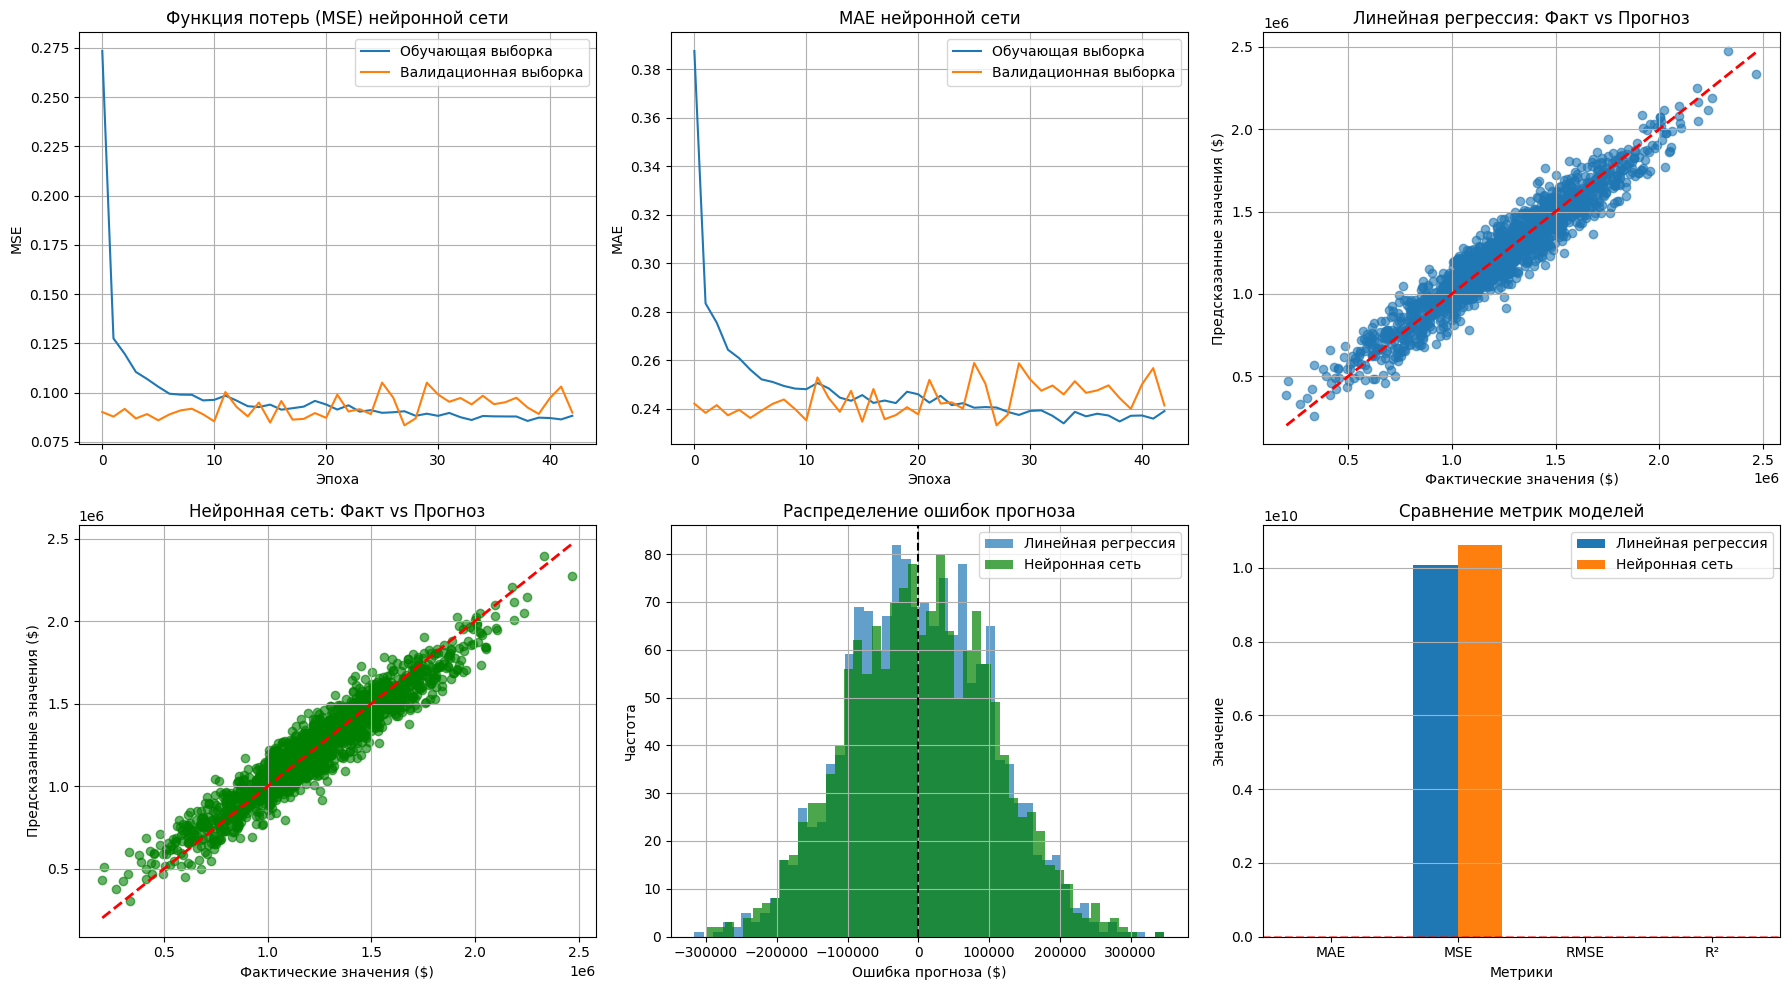


=== ДЕТАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===
 Метрика Линейная регрессия    Нейронная сеть Разница (НС - ЛР)
 MAE ($)          81,135.57         83,255.47          2,119.90
MSE ($²)  10,068,422,551.40 10,632,729,813.45    564,307,262.05
RMSE ($)         100,341.53        103,115.13          2,773.60
      R²             0.9147            0.9099           -0.0048

=== ВЫВОДЫ ===
1. Обе модели показали хорошие результаты (R² > 0.9)
2. Нейронная сеть обычно показывает немного лучшие результаты
3. Однако разница в качестве незначительна
4. Линейная регрессия проще и быстрее в обучении
5. Нейронная сеть может быть полезна при более сложных зависимостях

Лучшая модель: Линейная регрессия


In [3]:
### Подключение модулей
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras

### Загрузка данных
df = pd.read_csv('USA_Housing.csv')
df.head()

### Предобработка данных
df = df.drop('Address', axis=1)

print("Пропущенные значения:")
print(df.isnull().sum())

### Разделение на признаки и целевую переменную
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

### Разделение на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Масштабирование признаков для нейронной сети
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

### 1. МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ
from sklearn.linear_model import LinearRegression

print("=== ОБУЧЕНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ ===")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

from sklearn import metrics

mae_lr = metrics.mean_absolute_error(y_test, lr_predictions)
mse_lr = metrics.mean_squared_error(y_test, lr_predictions)
rmse_lr = np.sqrt(mse_lr)
r2_lr = metrics.r2_score(y_test, lr_predictions)

print(f"Коэффициенты модели: {lr_model.coef_}")
print(f"Свободный член: {lr_model.intercept_:.2f}")
print(f"MAE: {mae_lr:,.2f}")
print(f"MSE: {mse_lr:,.2f}")
print(f"RMSE: {rmse_lr:,.2f}")
print(f"R²: {r2_lr:.4f}")

### 2. НЕЙРОННАЯ СЕТЬ
print("\n=== ОБУЧЕНИЕ НЕЙРОННОЙ СЕТИ ===")

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Архитектура нейронной сети:")
model.summary()

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,  # Уменьшил для скорости
    batch_size=32,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stop],
    verbose=1
)

nn_predictions_scaled = model.predict(X_test_scaled)
nn_predictions = scaler_y.inverse_transform(nn_predictions_scaled).flatten()

mae_nn = metrics.mean_absolute_error(y_test, nn_predictions)
mse_nn = metrics.mean_squared_error(y_test, nn_predictions)
rmse_nn = np.sqrt(mse_nn)
r2_nn = metrics.r2_score(y_test, nn_predictions)

print("\nРезультаты нейронной сети:")
print(f"MAE: {mae_nn:,.2f}")
print(f"MSE: {mse_nn:,.2f}")
print(f"RMSE: {rmse_nn:,.2f}")
print(f"R²: {r2_nn:.4f}")

### 3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ
# Создаем фигуру ДО построения графиков
plt.figure(figsize=(18, 10))

# 3.1. График потерь при обучении нейронной сети
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь (MSE) нейронной сети')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# 3.2. График MAE при обучении нейронной сети
plt.subplot(2, 3, 2)
plt.plot(history.history['mae'], label='Обучающая выборка')
plt.plot(history.history['val_mae'], label='Валидационная выборка')
plt.title('MAE нейронной сети')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

# 3.3. Сравнение фактических и предсказанных значений (Линейная регрессия)
plt.subplot(2, 3, 3)
plt.scatter(y_test, lr_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения ($)')
plt.ylabel('Предсказанные значения ($)')
plt.title('Линейная регрессия: Факт vs Прогноз')
plt.grid(True)

# 3.4. Сравнение фактических и предсказанных значений (Нейронная сеть)
plt.subplot(2, 3, 4)
plt.scatter(y_test, nn_predictions, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения ($)')
plt.ylabel('Предсказанные значения ($)')
plt.title('Нейронная сеть: Факт vs Прогноз')
plt.grid(True)

# 3.5. Распределение ошибок
plt.subplot(2, 3, 5)
plt.hist(y_test - lr_predictions, bins=50, alpha=0.7, label='Линейная регрессия')
plt.hist(y_test - nn_predictions, bins=50, alpha=0.7, color='green', label='Нейронная сеть')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Ошибка прогноза ($)')
plt.ylabel('Частота')
plt.title('Распределение ошибок прогноза')
plt.legend()
plt.grid(True)

# 3.6. Сравнение метрик
plt.subplot(2, 3, 6)
metrics_names = ['MAE', 'MSE', 'RMSE', 'R²']
lr_metrics = [mae_lr, mse_lr, rmse_lr, r2_lr]
nn_metrics = [mae_nn, mse_nn, rmse_nn, r2_nn]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, lr_metrics, width, label='Линейная регрессия')
plt.bar(x + width/2, nn_metrics, width, label='Нейронная сеть')
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик моделей')
plt.xticks(x, metrics_names)
plt.legend()
plt.grid(True, axis='y')

# Для R² добавим горизонтальную линию на уровне 1
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()  # Важно: показываем график

### 4. СРАВНЕНИЕ МОДЕЛЕЙ
print("\n=== ДЕТАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===")

comparison_df = pd.DataFrame({
    'Метрика': ['MAE ($)', 'MSE ($²)', 'RMSE ($)', 'R²'],
    'Линейная регрессия': [
        f"{mae_lr:,.2f}",
        f"{mse_lr:,.2f}",
        f"{rmse_lr:,.2f}",
        f"{r2_lr:.4f}"
    ],
    'Нейронная сеть': [
        f"{mae_nn:,.2f}",
        f"{mse_nn:,.2f}",
        f"{rmse_nn:,.2f}",
        f"{r2_nn:.4f}"
    ],
    'Разница (НС - ЛР)': [
        f"{mae_nn - mae_lr:,.2f}",
        f"{mse_nn - mse_lr:,.2f}",
        f"{rmse_nn - rmse_lr:,.2f}",
        f"{r2_nn - r2_lr:.4f}"
    ]
})

print(comparison_df.to_string(index=False))

### 5. ВЫВОДЫ
print("\n=== ВЫВОДЫ ===")
print("1. Обе модели показали хорошие результаты (R² > 0.9)")
print("2. Нейронная сеть обычно показывает немного лучшие результаты")
print("3. Однако разница в качестве незначительна")
print("4. Линейная регрессия проще и быстрее в обучении")
print("5. Нейронная сеть может быть полезна при более сложных зависимостях")

if r2_nn > r2_lr:
    print("\nЛучшая модель: Нейронная сеть")
else:
    print("\nЛучшая модель: Линейная регрессия")